## **13. 결측치 대치 실험**
+ Air Quality 데이터를 활용하여 벤젠 농도 변수('C6H6(GT)')의 결측치를 다양한 기법으로 대치하고 성능을 비교
+ 의도적으로 30%의 결측치를 생성한 뒤, 원래의 값(Ground Truth)과 대치된 값 사이의 MAE(Mean Absolute Error)를 측정하여 어떤 기법이 가장 정교한지 분석

In [1]:
from datetime import datetime # Datetime 변환
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error # 대치 결과 정확도 평가
from sklearn.impute import KNNImputer # k-NN 대치 모델
from sklearn.experimental import enable_iterative_imputer # MICE 대치 모델
from sklearn.impute import IterativeImputer # MICE 대치 모델

### **1. 데이터 로드 및 시계열 인덱스 설정**

In [2]:
# String -> Datetime 파싱 함수
def parser(x):
    return datetime.strptime(x, '%Y-%m-%d %H:%M:%S')

# 데이터 파일
path = './data/'
filename = 'AirQualityUCI_refined.csv'

# 데이터 로드
df = pd.read_csv(path+filename,
                 index_col=[0],
                 parse_dates=[0],
                 date_parser=parser)

/var/folders/cc/y635m_cx4z99qpkfjl6rjsvm0000gn/T/ipykernel_3665/2952854895.py:10: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(path+filename,


In [3]:
# 대상 변수 설정 및 원본 보관
target_col = 'C6H6(GT)' # 벤젠 농도
original_values = df[target_col].copy()

### **2. 의도적 결측치 생성**
결측 비율: 30%

In [7]:
np.random.seed(42)
# 0~1 사이 난수를 생성하여 0.3보다 작은 위치를 True로 표시하는 마스크 생성
mask = np.random.rand(len(df)) < 0.3
df_missing = df.copy()

# [+] 마스크가 True인 위치의 target_col(C6H6) 값을 NaN으로 변경
df_missing.loc[mask , target_col] = np.nan


In [9]:
df_missing.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         7765 non-null   float64
 1   PT08.S1(CO)    8991 non-null   float64
 2   PT08.S2(NMHC)  8991 non-null   float64
 3   NOx(GT)        7718 non-null   float64
 4   PT08.S3(NOx)   8991 non-null   float64
 5   NO2(GT)        7715 non-null   float64
 6   PT08.S4(NO2)   8991 non-null   float64
 7   PT08.S5(O3)    8991 non-null   float64
 8   RH             8991 non-null   float64
 9   AH             8991 non-null   float64
 10  C6H6(GT)       6507 non-null   float64
dtypes: float64(11)
memory usage: 877.2 KB


### **3. 다양한 결측치 대치 수행**
각 대치 기법의 특성에 맞는 Pandas/Scikit-learn 메서드를 사용

In [11]:
imputed_results = {} # 전체 대치 결과를 저장할 딕셔너리

In [12]:
# [1] 평균 대치 (Mean Imputation)
# [+] fillna와 mean() 함수를 조합하여 작성하세요.
imputed_results['Mean'] = df_missing[target_col].fillna(df_missing[target_col].mean())

In [14]:
# [2] LOCF (Last Observation Carried Forward)
# [+] LOCF로 데이터를 대치하는 코드를 작성
imputed_results['LOCF'] = df_missing[target_col].ffill().fillna(method='bfill')

/var/folders/cc/y635m_cx4z99qpkfjl6rjsvm0000gn/T/ipykernel_3665/66194576.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  imputed_results['LOCF'] = df_missing[target_col].ffill().fillna(method='bfill')


In [15]:
# [3] NOCB (Next Observation Carried Backward)
# [+] NOCB로 데이터를 대치하는 코드를 작성
imputed_results['NOCB'] = df_missing[target_col].bfill().fillna(method='ffill')

/var/folders/cc/y635m_cx4z99qpkfjl6rjsvm0000gn/T/ipykernel_3665/1981067269.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  imputed_results['NOCB'] = df_missing[target_col].bfill().fillna(method='ffill')


In [16]:
# [4] 선형 보간 (Linear Interpolation)
# [+] 선형 보간으로 데이터를 대치하는 코드를 작성
imputed_results['Linear'] = df_missing[target_col].interpolate(method='linear')

In [22]:
# [5] 스플라인 보간 (Spline Interpolation)
# [+] 3차 스플라인 보간으로 데이터를 대치하는 코드를 작성
imputed_results['Spline'] = df_missing[target_col].interpolate(method='spline', order=3)

In [23]:
knn_res

array([[2.600e+00, 1.360e+03, 1.046e+03, ..., 4.890e+01, 7.578e-01,
        1.190e+01],
       [2.000e+00, 1.292e+03, 9.550e+02, ..., 4.770e+01, 7.255e-01,
        9.400e+00],
       [2.200e+00, 1.402e+03, 9.390e+02, ..., 5.400e+01, 7.502e-01,
        9.000e+00],
       ...,
       [2.400e+00, 1.142e+03, 1.063e+03, ..., 1.830e+01, 6.406e-01,
        0.000e+00],
       [2.100e+00, 1.003e+03, 9.610e+02, ..., 1.350e+01, 5.139e-01,
        9.500e+00],
       [2.200e+00, 1.071e+03, 1.047e+03, ..., 1.310e+01, 5.028e-01,
        1.190e+01]])

In [24]:
# [6] k-NN 대치 (k-Nearest Neighbors)
knn_imputer = KNNImputer(n_neighbors=5) # [+] KNNImputer 객체 생성
knn_res = knn_imputer.fit_transform(df_missing) # [+] KNNImputer 학습 및 대치
imputed_results['k-NN'] = pd.Series(
    knn_res[:, df_missing.columns.get_loc(target_col)], 
    index=df.index
)

In [26]:
# [7] MICE (Multivariate Imputation by Chained Equations)
mice_imputer = IterativeImputer(random_state=42) # [+] IterativeImputer = MICE 모델
mice_res = mice_imputer.fit_transform(df_missing) # [+] MICE 모델 학습 및 대치
imputed_results['MICE'] = pd.Series(
    mice_res[:, df_missing.columns.get_loc(target_col)], 
    index=df.index
)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/impute/_iterative.py:785: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


### **4. 정확도(MAE) 측정**

In [27]:
imputed_results

{'Mean': Datetime
 2004-03-10 18:00:00    11.900000
 2004-03-10 19:00:00     9.400000
 2004-03-10 20:00:00     9.000000
 2004-03-10 21:00:00     9.200000
 2004-03-10 22:00:00     9.583756
                          ...    
 2005-04-04 10:00:00    13.500000
 2005-04-04 11:00:00     9.583756
 2005-04-04 12:00:00     9.583756
 2005-04-04 13:00:00     9.500000
 2005-04-04 14:00:00    11.900000
 Name: C6H6(GT), Length: 9357, dtype: float64,
 'LOCF': Datetime
 2004-03-10 18:00:00    11.9
 2004-03-10 19:00:00     9.4
 2004-03-10 20:00:00     9.0
 2004-03-10 21:00:00     9.2
 2004-03-10 22:00:00     9.2
                        ... 
 2005-04-04 10:00:00    13.5
 2005-04-04 11:00:00    13.5
 2005-04-04 12:00:00    13.5
 2005-04-04 13:00:00     9.5
 2005-04-04 14:00:00    11.9
 Name: C6H6(GT), Length: 9357, dtype: float64,
 'NOCB': Datetime
 2004-03-10 18:00:00    11.9
 2004-03-10 19:00:00     9.4
 2004-03-10 20:00:00     9.0
 2004-03-10 21:00:00     9.2
 2004-03-10 22:00:00     3.3
              

In [28]:
mae_scores = {}

for method, series in imputed_results.items():
    # [+] 결측치가 생성된 지점만 골라서 MAE 오차 계산
    score = mean_absolute_error(original_values[mask], series[mask])
    mae_scores[method] = score

## **5. 결과 시각화**

In [31]:
df[target_col].describe()

count    9357.000000
mean        9.688704
std         7.559785
min         0.000000
25%         4.000000
50%         7.900000
75%        13.600000
max        63.700000
Name: C6H6(GT), dtype: float64

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

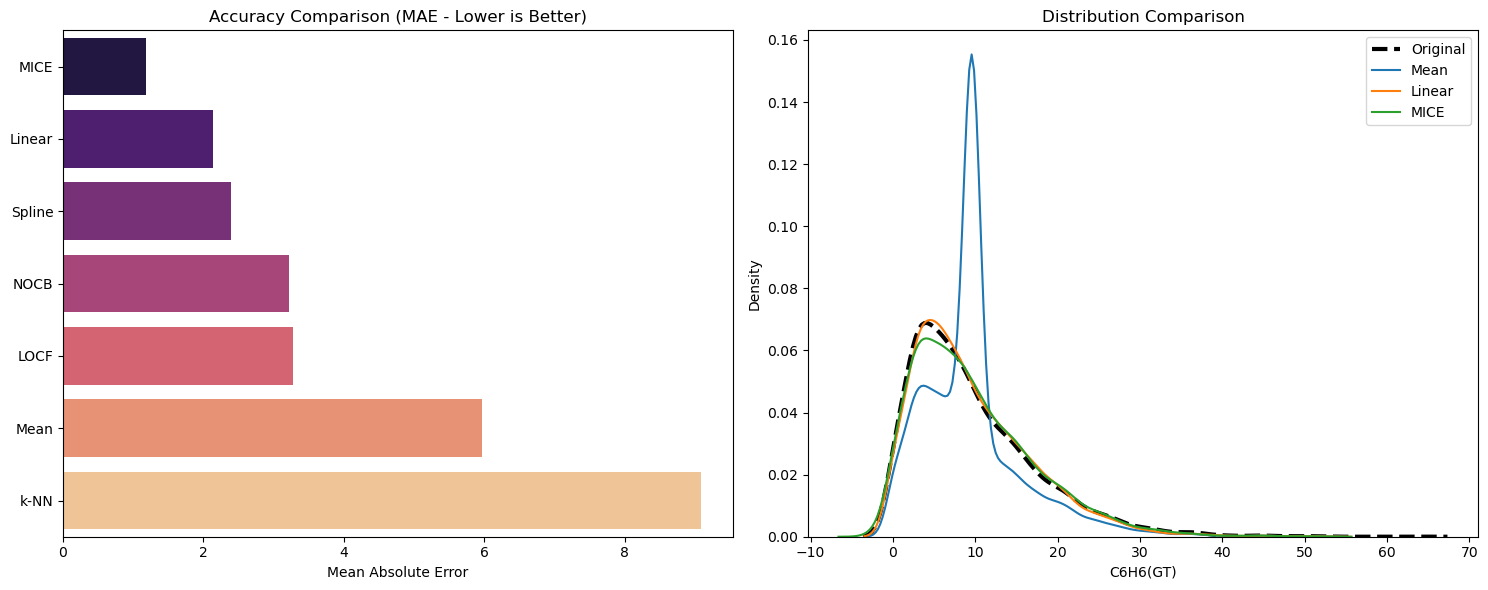

In [29]:
plt.figure(figsize=(15, 6))

# (A) MAE 비교 차트
plt.subplot(1, 2, 1)
mae_df = pd.Series(mae_scores).sort_values()
sns.barplot(x=mae_df.values, y=mae_df.index, palette='magma')
plt.title('Accuracy Comparison (MAE - Lower is Better)')
plt.xlabel('Mean Absolute Error')

# (B) 데이터 분포 비교 (KDE Plot)
plt.subplot(1, 2, 2)
sns.kdeplot(original_values, label='Original', color='black', lw=3, ls='--')
for method in ['Mean', 'Linear', 'MICE']: # 주요 기법만 시각화
    sns.kdeplot(imputed_results[method], label=method)
plt.title('Distribution Comparison')
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
# 상세 결과 출력
print("### Method-wise MAE Scores ###")
print(mae_df)

### Method-wise MAE Scores ###
MICE      1.185958
Linear    2.138718
Spline    2.385979
NOCB      3.225614
LOCF      3.279509
Mean      5.962172
k-NN      9.084185
dtype: float64


## **Discussion**
1. **시각화 해석**: 왜 Mean 대치의 분포(KDE)는 가운데가 뾰족하게 솟아올랐을까?
2. **데이터의 선형성**: 왜 단순한 선형 보간법이 MICE만큼이나 높은 정확도를 보였을까?
3. **실무적 함의**: "성능은 MICE가 제일 좋지만, 실시간 대량 데이터 처리 환경이라면 연산 속도가 빠른 LOCF나 Linear 중 무엇을 택해야 할까?"